In [1]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

In [2]:
genes = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\top_genes_annotated.csv"
)

print(genes.head())

      Probe_ID     F_Score           ID Gene symbol  \
0    211565_at  481.216276    211565_at      SH3GL3   
1  243689_s_at  297.991104  243689_s_at      FRG1BP   
2   1562755_at  276.654465   1562755_at         NaN   
3    220232_at  208.893237    220232_at        SCD5   
4    233103_at  204.729457    233103_at         NaN   

                                         Gene title  
0  SH3 domain containing GRB2 like 3, endophilin A3  
1    FSHD region gene 1 family member B, pseudogene  
2                                               NaN  
3                         stearoyl-CoA desaturase 5  
4                                               NaN  


In [3]:
gene_list = (
    genes["Gene symbol"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Number of genes:", len(gene_list))
print(gene_list[:20])

Number of genes: 377
['SH3GL3', 'FRG1BP', 'SCD5', 'ANKRD20A4///ANKRD20A2///ANKRD20A3///ANKRD20A1', 'KANK3', 'LOC441666', 'SCARA5', 'ESR1', 'TPX2', 'UBE2T', 'SLC35F6///CENPA', 'SCN4B', 'GPIHBP1', 'RECK', 'DNAH3', 'LINC00408', 'ECT2', 'CCNB2', 'CENPF', 'UBE2C']


In [7]:
print(len(gene_list))
print(gene_list[:20])

377
['SH3GL3', 'FRG1BP', 'SCD5', 'ANKRD20A4///ANKRD20A2///ANKRD20A3///ANKRD20A1', 'KANK3', 'LOC441666', 'SCARA5', 'ESR1', 'TPX2', 'UBE2T', 'SLC35F6///CENPA', 'SCN4B', 'GPIHBP1', 'RECK', 'DNAH3', 'LINC00408', 'ECT2', 'CCNB2', 'CENPF', 'UBE2C']


In [5]:
import gseapy as gp

print(gp.__version__)

1.3.0


In [8]:
import gseapy as gp

go_bp = gp.enrichr(
    gene_list=gene_list,
    gene_sets=["GO_Biological_Process_2023"],
    organism="human",
    outdir=r"C:\Research_Paper_Project\Project\results\GO_BP",
    cutoff=0.05
)

print(go_bp.results.head())

                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   

                                                Term Overlap       P-value  \
0          Mitotic Spindle Organization (GO:0007052)   19/85  1.481837e-15   
1  Microtubule Cytoskeleton Organization Involved...   16/59  9.712256e-15   
2  Mitotic Sister Chromatid Segregation (GO:0000070)  20/111  2.177821e-14   
3  Positive Regulation Of Cell Cycle Process (GO:...  18/118  8.484736e-12   
4  Spindle Assembly Checkpoint Signaling (GO:0071...   10/26  2.041986e-11   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      2.914773e-12            0                     0   15.726384   
1      9.552004e-12            0                     0   20.181666   
2      1.427925e-11            0                     0   12.024502   
3      4.172369e-09            0                    

In [9]:
go_bp.results.to_csv(
    r"C:\Research_Paper_Project\Project\results\GO_BP_results.csv",
    index=False
)

print("GO Biological Process Results Saved")

GO Biological Process Results Saved


In [10]:
top20 = go_bp.results.sort_values(
    by="Adjusted P-value"
).head(20)

print(top20)

                      Gene_set  \
0   GO_Biological_Process_2023   
1   GO_Biological_Process_2023   
2   GO_Biological_Process_2023   
3   GO_Biological_Process_2023   
4   GO_Biological_Process_2023   
5   GO_Biological_Process_2023   
6   GO_Biological_Process_2023   
7   GO_Biological_Process_2023   
8   GO_Biological_Process_2023   
9   GO_Biological_Process_2023   
10  GO_Biological_Process_2023   
11  GO_Biological_Process_2023   
12  GO_Biological_Process_2023   
13  GO_Biological_Process_2023   
15  GO_Biological_Process_2023   
14  GO_Biological_Process_2023   
16  GO_Biological_Process_2023   
17  GO_Biological_Process_2023   
18  GO_Biological_Process_2023   
19  GO_Biological_Process_2023   

                                                 Term Overlap       P-value  \
0           Mitotic Spindle Organization (GO:0007052)   19/85  1.481837e-15   
1   Microtubule Cytoskeleton Organization Involved...   16/59  9.712256e-15   
2   Mitotic Sister Chromatid Segregation (GO:000

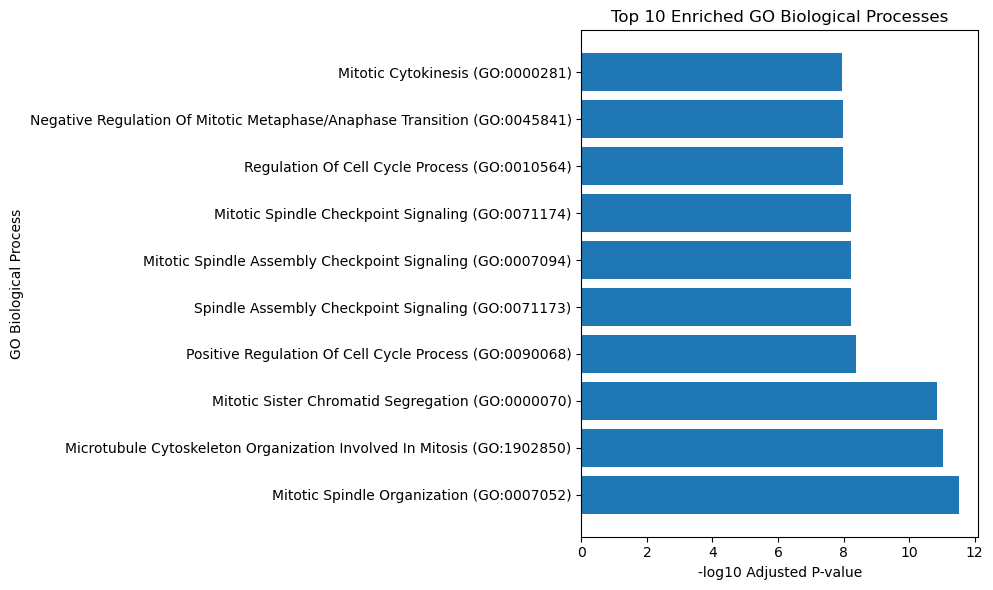

In [11]:
import matplotlib.pyplot as plt
import numpy as np

top10 = go_bp.results.sort_values(
    by="Adjusted P-value"
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Term"],
    -np.log10(top10["Adjusted P-value"])
)

plt.xlabel("-log10 Adjusted P-value")
plt.ylabel("GO Biological Process")
plt.title("Top 10 Enriched GO Biological Processes")

plt.tight_layout()

plt.savefig(
    r"C:\Research_Paper_Project\Project\figures\GO_BP_Barplot.png",
    dpi=300
)

plt.show()

In [12]:
kegg = gp.enrichr(
    gene_list=gene_list,
    gene_sets=["KEGG_2021_Human"],
    organism="human",
    outdir=r"C:\Research_Paper_Project\Project\results\KEGG",
    cutoff=0.05
)

print(kegg.results.head())

          Gene_set                                     Term Overlap  \
0  KEGG_2021_Human                               Cell cycle  20/124   
1  KEGG_2021_Human                           Oocyte meiosis  16/129   
2  KEGG_2021_Human                          DNA replication    8/36   
3  KEGG_2021_Human  Progesterone-mediated oocyte maturation  12/100   
4  KEGG_2021_Human                          Mismatch repair    6/23   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  1.953914e-13      4.650315e-11            0                     0   
1  2.845824e-09      3.386530e-07            0                     0   
2  2.823271e-07      2.239795e-05            0                     0   
3  3.997228e-07      2.378351e-05            0                     0   
4  3.317455e-06      1.579109e-04            0                     0   

   Odds Ratio  Combined Score  \
0   10.514437      307.692071   
1    7.652293      150.577337   
2   15.172280      228.801014   
3    7.2

In [13]:
kegg.results.to_csv(
    r"C:\Research_Paper_Project\Project\results\KEGG_results.csv",
    index=False
)

print("KEGG Results Saved")

KEGG Results Saved


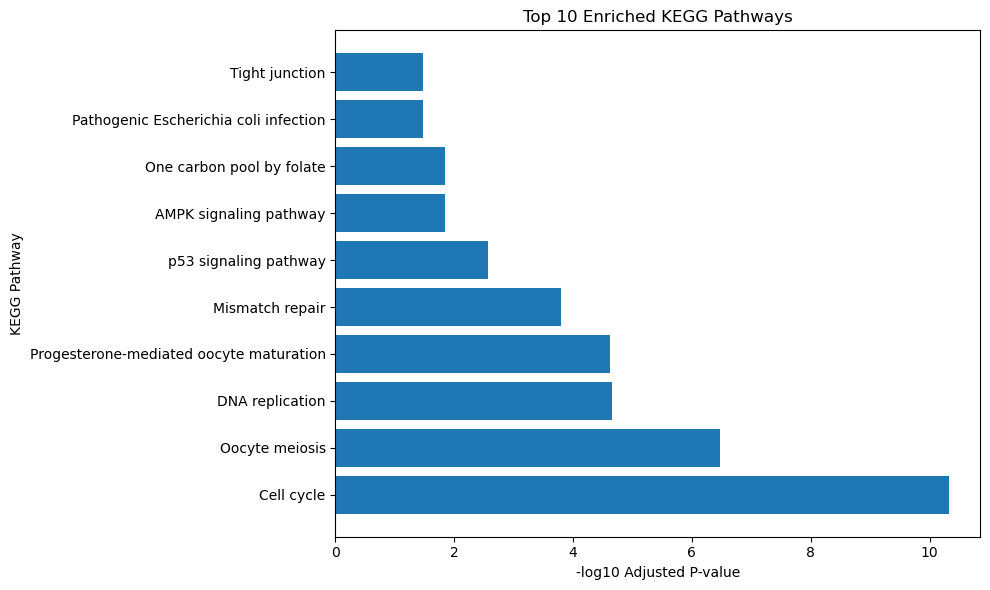

In [14]:
top10 = kegg.results.sort_values(
    by="Adjusted P-value"
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Term"],
    -np.log10(top10["Adjusted P-value"])
)

plt.xlabel("-log10 Adjusted P-value")
plt.ylabel("KEGG Pathway")
plt.title("Top 10 Enriched KEGG Pathways")

plt.tight_layout()

plt.savefig(
    r"C:\Research_Paper_Project\Project\figures\KEGG_Pathways.png",
    dpi=300
)

plt.show()

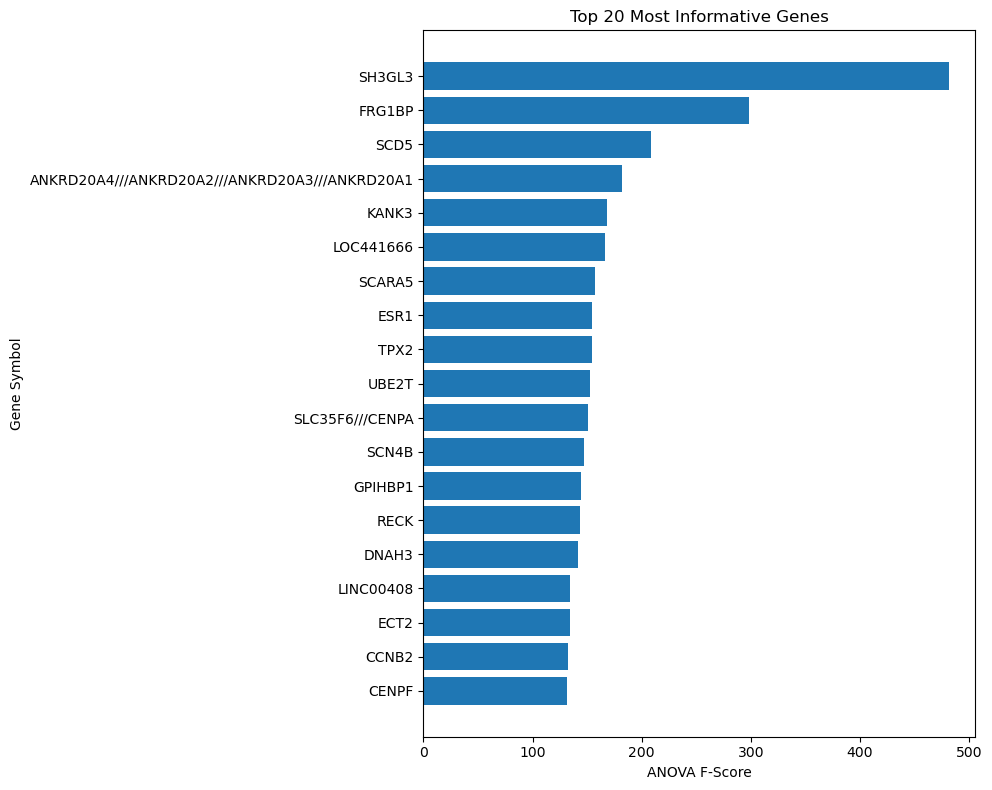

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load top genes
top_genes = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\top_genes_annotated.csv"
)

# Top 20 genes
top20 = top_genes.head(20)

plt.figure(figsize=(10,8))

top20 = top_genes.dropna(subset=["Gene symbol"]).head(20)

plt.barh(
    top20["Gene symbol"],
    top20["F_Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("ANOVA F-Score")
plt.ylabel("Gene Symbol")
plt.title("Top 20 Most Informative Genes")

plt.tight_layout()

plt.savefig(
    r"C:\Research_Paper_Project\Project\figures\Top20_Genes.png",
    dpi=300
)

plt.show()

In [17]:
import pandas as pd

X = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\clean_dataset.csv",
    index_col=0
)

labels = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\labels.csv"
)

X["Subtype"] = labels["Subtype"]

X.to_csv(
    r"C:\Research_Paper_Project\Project\results\Final_Dataset.csv",
    index=True
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest",
        "XGBoost"
    ],
    "Test Accuracy": [
        1.0000,
        1.0000,
        0.9655,
        0.9655
    ],
    "Cross Validation Mean": [
        0.9462,
        0.9644,
        0.9462,
        0.9012
    ],
    "CV Standard Deviation": [
        0.0186,
        0.0178,
        0.0447,
        0.0522
    ]
})

results.to_csv(
    r"C:\Research_Paper_Project\Project\results\Model_Comparison.csv",
    index=False
)

print(results)

                    Model  Test Accuracy  Cross Validation Mean  \
0     Logistic Regression         1.0000                 0.9462   
1  Support Vector Machine         1.0000                 0.9644   
2           Random Forest         0.9655                 0.9462   
3                 XGBoost         0.9655                 0.9012   

   CV Standard Deviation  
0                 0.0186  
1                 0.0178  
2                 0.0447  
3                 0.0522  


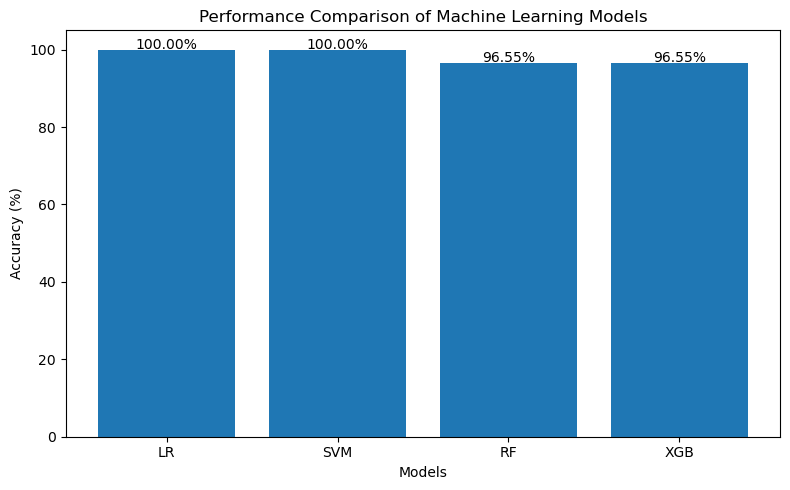

In [19]:
import matplotlib.pyplot as plt

models = [
    "LR",
    "SVM",
    "RF",
    "XGB"
]

accuracy = [
    100,
    100,
    96.55,
    96.55
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Performance Comparison of Machine Learning Models")

for i, value in enumerate(accuracy):
    plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.ylim(0, 105)

plt.tight_layout()

plt.savefig(
    r"C:\Research_Paper_Project\Project\figures\Model_Comparison.png",
    dpi=300
)

plt.show()